## Data Cleaning, Filtering, Balancing, and Feature Selection Pipeline
Notebook section này triển khai đầy đủ các bước tiền xử lý và lựa chọn đặc trưng theo quy trình sau:
1. **Data Cleaning & Filtering**: xử lý missing values, loại cột không liên quan, và chuẩn hóa kiểu dữ liệu.
2. **Variance + Correlation Analysis**: dùng phân tích phương sai để lọc biến có độ phân tán thấp, sau đó dùng ma trận tương quan để đọc quan hệ nội bộ giữa các thuộc tính.
3. **Class Balancing (Re-sampling)**: cân bằng lớp bằng cách thêm các dòng dữ liệu giả (dummy rows) cho lớp thiểu số thông qua lấy mẫu lại có nhiễu nhẹ.
4. **Feature Selection - Uni-variate**: áp dụng phương pháp đơn biến để chọn các đặc trưng có mức độ liên quan cao với biến mục tiêu.
5. **Feature Selection - GSA (Binary Encoding)**: dùng thuật toán Gravitational Search Algorithm với biểu diễn nhị phân (`1`: chọn, `0`: không chọn) và fitness dựa trên việc giảm error rate để tăng độ chính xác phân loại.

Shape sau cleaning: (594194, 19)
Số cột numeric: 4 | categorical: 15


,variance
TotalCharges,5.540924e+06
MonthlyCharges,9.651861e+02
tenure,6.280999e+02
SeniorCitizen,1.010833e-01


Giữ lại sau variance threshold (0.01): 4
Loại bỏ do variance thấp: None

Top 10 |corr| với target:


,abs_corr_with_target
tenure,0.418453
MonthlyCharges,0.272997
SeniorCitizen,0.236362
TotalCharges,0.218365


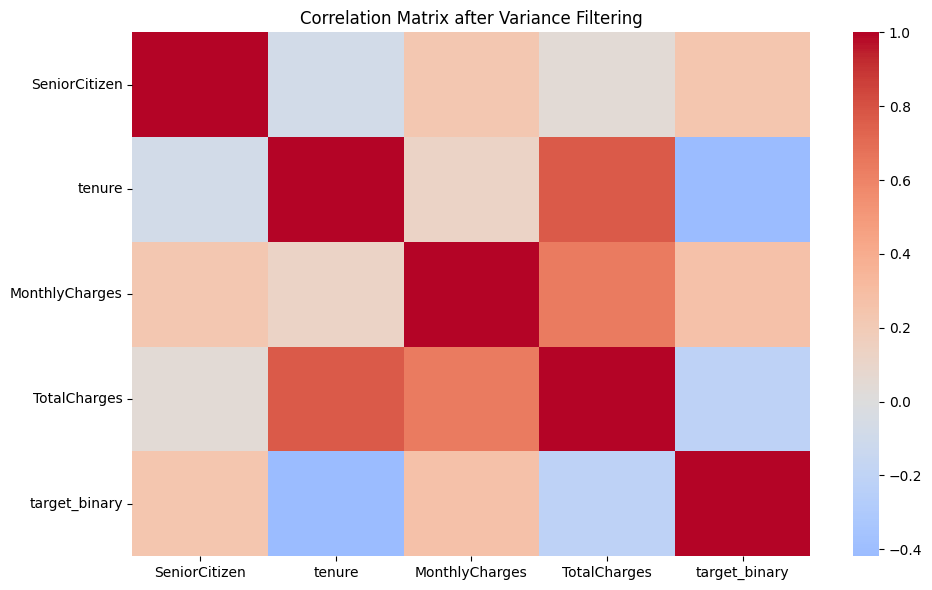


Phân phối lớp trước cân bằng:


,count
target_binary,
0,460377
1,133817



Phân phối lớp sau cân bằng:


,count
target_binary,
0,460377
1,460377



Top đặc trưng theo uni-variate selection:


,feature,uni_variate_score
1,tenure,0.418759
2,MonthlyCharges,0.401792
0,SeniorCitizen,0.366430
3,TotalCharges,0.349694
20,Contract_Month-to-month,0.307076
24,PaymentMethod_Electronic check,0.254107
10,OnlineSecurity_No,0.250871
16,TechSupport_No,0.239929
8,InternetService_Fiber optic,0.238708
23,PaperlessBilling_Yes,0.173331


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

if 'train_df' not in globals():
    train_df = pd.read_csv('../data/train.csv')
if 'test_df' not in globals():
    test_df = pd.read_csv('../data/test.csv')

# ------------------------------------------------------------------
# 1) DATA CLEANING & FILTERING
# ------------------------------------------------------------------
clean_df = train_df.copy()

irrelevant_cols = [c for c in ['id'] if c in clean_df.columns]
if irrelevant_cols:
    clean_df = clean_df.drop(columns=irrelevant_cols)

target_col = 'Churn'
clean_df[target_col] = clean_df[target_col].astype(str).str.strip().str.lower()
clean_df = clean_df[clean_df[target_col].isin(['yes', 'no'])].copy()
clean_df['target_binary'] = clean_df[target_col].map({'yes': 1, 'no': 0})

X = clean_df.drop(columns=[target_col, 'target_binary'])
y = clean_df['target_binary'].astype(int)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

for col in categorical_cols.copy():
    converted = pd.to_numeric(X[col], errors='coerce')
    if converted.notna().mean() > 0.95:
        X[col] = converted
        numeric_cols.append(col)
        categorical_cols.remove(col)

numeric_cols = list(dict.fromkeys(numeric_cols))
print('Shape sau cleaning:', X.shape)
print('Số cột numeric:', len(numeric_cols), '| categorical:', len(categorical_cols))

# ------------------------------------------------------------------
# 2) VARIANCE ANALYSIS + CORRELATION MATRIX
# ------------------------------------------------------------------
X_num_imputed = X[numeric_cols].copy() if numeric_cols else pd.DataFrame(index=X.index)
if not X_num_imputed.empty:
    X_num_imputed = X_num_imputed.fillna(X_num_imputed.median(numeric_only=True))
    variance_series = X_num_imputed.var(numeric_only=True).sort_values(ascending=False)
    display(variance_series.to_frame('variance'))

    vt = VarianceThreshold(threshold=0.01)
    vt.fit(X_num_imputed)
    kept_by_variance = X_num_imputed.columns[vt.get_support()].tolist()
    removed_by_variance = [c for c in X_num_imputed.columns if c not in kept_by_variance]

    print('Giữ lại sau variance threshold (0.01):', len(kept_by_variance))
    print('Loại bỏ do variance thấp:', removed_by_variance if removed_by_variance else 'None')

    corr_source = X_num_imputed[kept_by_variance].copy()
    corr_source['target_binary'] = y.values
    corr_matrix = corr_source.corr(numeric_only=True)

    corr_with_target = corr_matrix['target_binary'].drop('target_binary').abs().sort_values(ascending=False).head(10)
    print('\nTop 10 |corr| với target:')
    display(corr_with_target.to_frame('abs_corr_with_target'))

    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix after Variance Filtering')
    plt.tight_layout()
    plt.show()
else:
    print('Không có cột numeric để phân tích variance/correlation.')

# ------------------------------------------------------------------
# 3) CLASS BALANCING (RE-SAMPLING + DUMMY ROWS)
# ------------------------------------------------------------------
balanced_df = pd.concat([X, y.rename('target_binary')], axis=1).copy()
class_counts = balanced_df['target_binary'].value_counts()
print('\nPhân phối lớp trước cân bằng:')
display(class_counts.to_frame('count'))

if len(class_counts) == 2:
    minority_class = class_counts.idxmin()
    majority_n = class_counts.max()
    minority_df = balanced_df[balanced_df['target_binary'] == minority_class].copy()

    n_to_add = majority_n - class_counts.min()
    if n_to_add > 0:
        rng = np.random.default_rng(42)
        sampled_idx = rng.choice(minority_df.index.values, size=n_to_add, replace=True)
        dummy_rows = minority_df.loc[sampled_idx].copy()

        num_for_noise = [c for c in numeric_cols if c in dummy_rows.columns]
        for col in num_for_noise:
            std = np.nanstd(dummy_rows[col].values.astype(float))
            noise_scale = 0.01 * std if std > 0 else 0.0
            if noise_scale > 0:
                dummy_rows[col] = dummy_rows[col].astype(float) + rng.normal(0, noise_scale, size=len(dummy_rows))

        balanced_df = pd.concat([balanced_df, dummy_rows], axis=0, ignore_index=True)
else:
    print('Target chỉ có 1 lớp. Bỏ qua class balancing.')

print('\nPhân phối lớp sau cân bằng:')
display(balanced_df['target_binary'].value_counts().to_frame('count'))

X_bal = balanced_df.drop(columns=['target_binary'])
y_bal = balanced_df['target_binary'].astype(int)

# ------------------------------------------------------------------
# 4) UNI-VARIATE FEATURE SELECTION
# ------------------------------------------------------------------
num_cols_bal = X_bal.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_bal = [c for c in X_bal.columns if c not in num_cols_bal]

numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_cols_bal),
        ('cat', categorical_pipe, cat_cols_bal),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
 )

X_bal_enc = preprocessor.fit_transform(X_bal)
feature_names = preprocessor.get_feature_names_out()

k_uni = min(25, X_bal_enc.shape[1])
uni_selector = SelectKBest(score_func=mutual_info_classif, k=k_uni)
uni_selector.fit(X_bal_enc, y_bal)
uni_mask = uni_selector.get_support()
uni_table = pd.DataFrame({
    'feature': feature_names[uni_mask],
    'uni_variate_score': uni_selector.scores_[uni_mask],
}).sort_values('uni_variate_score', ascending=False)

print('\nTop đặc trưng theo uni-variate selection:')
display(uni_table.head(20))

# ------------------------------------------------------------------
# 5) GSA-BASED FEATURE SELECTION (BINARY ENCODING)
# ------------------------------------------------------------------
def gsa_feature_selection(
    X_matrix,
    y_vec,
    feature_names,
    n_agents=12,
    n_iters=10,
    alpha=20,
    random_state=42,
    cv_splits=5,
    max_features_ratio=0.60,
    min_features=3,
 ):
    rng = np.random.default_rng(random_state)
    n_features = X_matrix.shape[1]
    agents = rng.integers(0, 2, size=(n_agents, n_features), dtype=int)

    for i in range(n_agents):
        if agents[i].sum() < min_features:
            agents[i, rng.choice(n_features, size=min_features, replace=False)] = 1

    max_features = max(min_features, int(max_features_ratio * n_features))
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    def fitness(mask):
        selected = np.where(mask == 1)[0]
        if len(selected) < min_features or len(selected) > max_features:
            return 1.0
        X_sub = X_matrix[:, selected]
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(solver='saga', max_iter=8000, tol=1e-3, random_state=42)),
        ])
        scores = cross_val_score(model, X_sub, y_vec, cv=cv, scoring='roc_auc')
        return float(1 - scores.mean())

    best_mask = None
    best_fit = np.inf
    velocity = rng.normal(0, 0.2, size=(n_agents, n_features))

    for t in range(1, n_iters + 1):
        fits = np.array([fitness(agent) for agent in agents])

        idx_best = np.argmin(fits)
        if fits[idx_best] < best_fit:
            best_fit = fits[idx_best]
            best_mask = agents[idx_best].copy()

        worst_fit = np.max(fits)
        best_fit_iter = np.min(fits)
        if worst_fit == best_fit_iter:
            masses = np.ones(n_agents) / n_agents
        else:
            raw_mass = (worst_fit - fits) / (worst_fit - best_fit_iter + 1e-12)
            masses = raw_mass / (raw_mass.sum() + 1e-12)

        G = np.exp(-alpha * t / n_iters)

        for i in range(n_agents):
            force = np.zeros(n_features)
            for j in range(n_agents):
                if i == j:
                    continue
                distance = np.linalg.norm(agents[j] - agents[i]) + 1e-12
                rand_vec = rng.random(n_features)
                force += rand_vec * G * masses[j] * (agents[j] - agents[i]) / distance

            acceleration = force / (masses[i] + 1e-12)
            velocity[i] = rng.random(n_features) * velocity[i] + acceleration

        stable_velocity = np.clip(velocity, -50, 50)
        prob = 1 / (1 + np.exp(-stable_velocity))
        agents = (rng.random((n_agents, n_features)) < prob).astype(int)

        for i in range(n_agents):
            s = agents[i].sum()
            if s < min_features:
                off_idx = np.where(agents[i] == 0)[0]
                if len(off_idx) > 0:
                    turn_on = rng.choice(off_idx, size=min_features - s, replace=False)
                    agents[i, turn_on] = 1
            elif s > max_features:
                on_idx = np.where(agents[i] == 1)[0]
                turn_off = rng.choice(on_idx, size=s - max_features, replace=False)
                agents[i, turn_off] = 0

    selected_idx = np.where(best_mask == 1)[0]
    return feature_names[selected_idx], best_fit

gsa_selected_features, gsa_best_error = gsa_feature_selection(
    X_bal_enc, y_bal.values, feature_names, random_state=42
 )

gsa_table = pd.DataFrame({'gsa_selected_feature': gsa_selected_features})
print('\nSố đặc trưng được GSA chọn (encoded):', len(gsa_selected_features))
print('Best fitness (1 - ROC-AUC) từ GSA:', round(gsa_best_error, 5))
display(gsa_table.head(30))

# Map encoded feature names về cột gốc để model_selection có thể dùng trực tiếp
def map_encoded_to_raw(encoded_features, numeric_base_cols, categorical_base_cols):
    raw_features = []
    for feat in encoded_features:
        if feat in numeric_base_cols:
            raw_features.append(feat)
            continue
        matched = False
        for c in categorical_base_cols:
            prefix = f"{c}_"
            if str(feat).startswith(prefix):
                raw_features.append(c)
                matched = True
                break
        if not matched and feat in categorical_base_cols:
            raw_features.append(feat)
    # Preserve order and uniqueness
    return list(dict.fromkeys(raw_features))

gsa_selected_raw_features = map_encoded_to_raw(
    list(map(str, gsa_selected_features)),
    num_cols_bal,
    cat_cols_bal,
)
print('Số cột gốc suy ra từ GSA:', len(gsa_selected_raw_features))
print('Raw selected features (sample):', gsa_selected_raw_features[:15])

if len(gsa_selected_features) > 0:
    feature_list = list(feature_names)
    gsa_idx = [feature_list.index(f) for f in gsa_selected_features]
    X_gsa = X_bal_enc[:, gsa_idx]
    quick_model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(solver='saga', max_iter=8000, tol=1e-3, random_state=42)),
    ])
    quick_scores = cross_val_score(
        quick_model,
        X_gsa,
        y_bal,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
    )
    print('ROC-AUC CV (GSA features):', round(float(quick_scores.mean()), 4), '+/-', round(float(quick_scores.std()), 4))

    out_path = Path('../models/selected_features_gsa.json')
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open('w', encoding='utf-8') as f:
        json.dump(
            {
                'selected_features_raw': gsa_selected_raw_features,
                'selected_features_transformed': list(map(str, gsa_selected_features)),
                'metric': 'roc_auc',
            },
            f,
            ensure_ascii=False,
            indent=2,
        )
    print('Saved selected features to:', out_path)